# 🚦 Traffic Junction Signal Renderer
**Pipeline:** PDF → JSON (coordinates + timing) → SVG visualisation

Supports multi-junction PDFs in the Bangalore BBMP / ADUGODI format.
Renders a dark-theme signal-bubble diagram with v/c ratio warnings and phase summary.

| Step | Cell(s) | Output |
|------|---------|--------|
| 1. Install & import | 1–2 | — |
| 2. Parse PDF → clean text | 3 | raw text string |
| 3. Build structured JSON | 4–5 | `<stem>_junctions.json` |
| 4. Compute v/c ratios | 6 | analysis dict per phase |
| 5. Render SVG | 7–8 | inline display + `.svg` files |
| 6. Interactive explorer | 9 | ipywidgets time-slot picker |

In [126]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────
import subprocess, sys

for pkg in ["pypdf", "pdfplumber", "ipywidgets"]:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg,
         "--break-system-packages", "-q"],
        stderr=subprocess.DEVNULL
    )

print("✅ Dependencies ready.")

✅ Dependencies ready.


In [127]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────
import re
import json
import math
from pathlib import Path
from pypdf import PdfReader
from IPython.display import SVG, display, HTML

print("✅ Imports OK.")

✅ Imports OK.


---
## Step 1 — Parse PDF

In [260]:
# ── Cell 3: PDF text extractor ────────────────────────────────
# ╔══════════════════════════════════════════╗
# ║  SET YOUR PDF PATH HERE                 ║
# ╚══════════════════════════════════════════╝
PDF_PATH = "yelahanka 1.pdf"   # ← change to your file

import pdfplumber
print("✅ pdfplumber configured for parsing.")

✅ pdfplumber configured for parsing.


---
## Step 2 — Parse Text → Structured JSON

The parser works in three phases:
1. **Block splitter** — finds JUNCTION headers and divides the text
2. **Approach parser** — extracts leg letter, from-street, turn movements
3. **Timing parser** — extracts the time-band table with weekday/sunday values

In [261]:
# ── Cell 4: Parser functions ────────────────────────────────
import re, math

CANVAS_W, CANVAS_H = 900, 560
CX, CY   = CANVAS_W // 2, CANVAS_H // 2
ARM_LEN  = 165
DIR_ANGLE = {"E": 0, "N": 90, "W": 180, "S": 270}
STREET_DIR = {
    "UCO BANK": "E",   "MICO BANDE": "W",  "ANEPALYA": "W",
    "KORAMANGALA": "N", "JAKKASANDRA": "S",  "KRUPANIDHI": "E",
    "WIPRO": "S",       "VENKATAPURA": "N",   "HOSUR": "S",
}

def street_to_direction(name: str) -> str:
    for kw, d in STREET_DIR.items():
        if kw in name.upper():
            return d
    return "?"

def deduplicate_text(text):
    if not text: return ""
    text = text.replace('\n', ' ')
    res = ""
    i = 0
    t = text.strip()
    while i < len(t):
        res += t[i]
        if i + 1 < len(t) and t[i+1] == t[i] and t[i].isalpha(): i += 2
        else: i += 1
    half = len(res)//2
    if half > 0 and res[:half].strip() == res[half:].strip(): return res[:half].strip()
    return res

def assign_coordinates(approaches: list) -> list:
    default_by_leg = {"A": 0, "B": 90, "C": 180, "D": 270}
    used, result   = set(), []
    for ap in approaches:
        angle = DIR_ANGLE.get(ap["direction"])
        if angle is None or angle in used:
            angle = default_by_leg.get(ap["leg"])
        if angle is None or angle in used:
            angle = next((a for a in [0,90,180,270] if a not in used), 0)
        used.add(angle)
        rad = math.radians(angle)
        result.append({**ap,
            "angle_deg": angle,
            "cx": round(CX + ARM_LEN * math.cos(rad)),
            "cy": round(CY - ARM_LEN * math.sin(rad)),
        })
    return result

def build_junction_json(pdf_path: str) -> dict:
    pdf = pdfplumber.open(pdf_path)
    junctions = []
    for page in pdf.pages:
        text_lines = page.extract_text().split('\n')
        tables = page.extract_tables()
        layout_lines = page.extract_text(layout=True).split('\n')
        for t_idx, table in enumerate(tables):
            approaches = []
            timings = []
            name = f"Junction {t_idx+1}"
            control = "FIXED"
            for i, line in enumerate(text_lines):
                if 'JUNCTION' in line.upper() and ('FIXED' in line.upper() or 'VAC' in line.upper()):
                    name = re.sub(r'[,-]?\s*(?:FIXED|VAC|ACTUATED|ADAPTIVE).*$', '', line, flags=re.I).strip()
                    ctrl_m = re.search(r'(FIXED|VAC|ACTUATED|ADAPTIVE)', line, re.I)
                    if ctrl_m: control = ctrl_m.group(1).upper()
            for row in table:
                if not row: continue
                if len(row) > 2 and row[1] and row[1].strip() in ('A', 'B', 'C', 'D'):
                    leg = row[1].strip()
                    from_str = deduplicate_text(row[2] if row[2] else "")
                    movements = [deduplicate_text(c) for c in row[3:] if c and c.strip()]
                    mvs = re.findall(r'[LRS]', " ".join(movements))
                    approaches.append({"leg": leg, "from": from_str, "direction": street_to_direction(from_str), "movements": mvs})
            for line in layout_lines:
                m = re.search(r'(\d{2}:\d{2})\s+(\d{2}:\d{2})\s+((?:\d+(?:\s*\(\d+\))?\s*){3,})', line)
                if m:
                    nums = [{"weekday": int(n.group(1)), "sunday": int(n.group(2)) if n.group(2) else int(n.group(1))}
                            for n in re.finditer(r'(\d+)(?:\s*\((\d+)\))?', m.group(3))]
                    if len(nums) < 3: continue
                    # Avoid duplicate timings
                    if not any(t["from_time"] == m.group(1) for t in timings):
                        timings.append({"from_time": m.group(1), "to_time": m.group(2), "phase_greens": nums[:-2], "ped_phase": nums[-2], "cycle_time": nums[-1]})
            if approaches:
                approaches = assign_coordinates(approaches)
                junctions.append({"id": len(junctions)+1, "name": name, "control": control, 
                                  "canvas": {"width": CANVAS_W, "height": CANVAS_H, "cx": CX, "cy": CY},
                                  "approaches": approaches, "timings": timings})
    return {"junctions": junctions}
print("✅ Parser functions defined.")

✅ Parser functions defined.


In [262]:
# ── Cell 5: Parse & save JSON ───────────────────────────────
import json
from pathlib import Path
junction_json = build_junction_json(PDF_PATH)

json_out = Path(PDF_PATH).stem + "_junctions.json"
with open(json_out, "w", encoding="utf-8") as f:
    json.dump(junction_json, f, indent=2)
print(f"\n💾 Saved: {json_out}")

for jn in junction_json["junctions"]:
    print(f"\n📍 {jn['name']} [{jn['control']}]")
    print(f"   Approaches: {[a['leg']+'/'+a['from'] for a in jn['approaches']]}")
    if jn['timings']:
        pk = jn['timings'][1] if len(jn['timings'])>1 else jn['timings'][0]
        print(f"   Peak cycle ({pk['from_time']}–{pk['to_time']}): "
              f"{pk['cycle_time']['weekday']}s weekday / "
              f"{pk['cycle_time']['sunday']}s sunday")


💾 Saved: yelahanka 1_junctions.json

📍 YELAHANKACIRCLEJUNCTION,YELAHANKAPOLICESTATION [FIXED]
   Approaches: ['A/DEVANAHALI', 'B/HEBAL', 'C/KOGILU', 'D/YELAHANKA POLICESTATION']
   Peak cycle (07:00–08:30): 120s weekday / 120s sunday

📍 YELAHANKACIRCLEJUNCTION,YELAHANKAPOLICESTATION [FIXED]
   Approaches: ['A/YELAHANKA BYPAS', 'B/DODABALAPURA', 'C/KOGILUCROSS']
   Peak cycle (07:00–08:30): 120s weekday / 120s sunday


---
## Step 3 — Compute v/c Ratios

Uses the formula:  
`v/c ≈ (C / G_eff) × PHF × k`  
where `G_eff = green − lost_time`, `PHF = 0.92`, `k = 0.18` (calibrated to Bangalore peak traffic).

In [263]:
# ── Cell 6: v/c analysis ───────────────────────────────────────────────────
LOST_TIME_PER_PHASE = 3   # seconds
PEAK_HOUR_FACTOR    = 0.92
DEMAND_FACTOR       = 0.18  # calibrated for Bangalore corridors

STATUS_THRESHOLDS = {"critical": 1.0, "warning": 0.85}  # v/c > threshold → status


def compute_vc_ratios(junction: dict, slot_idx: int = 1) -> list:
    """
    Compute v/c ratio for each signalled phase.
    slot_idx: index into timings list (0=07-08, 1=08-11 peak, …)
    """
    timings = junction.get("timings", [])
    if not timings:
        return []
    slot   = timings[min(slot_idx, len(timings) - 1)]
    cycle  = slot["cycle_time"]["weekday"]
    phases = slot["phase_greens"]
    ped    = slot["ped_phase"]["weekday"]
    legs   = junction.get("approaches", [])

    results = []
    for i, phase in enumerate(phases):
        g     = phase["weekday"]
        g_eff = max(g - LOST_TIME_PER_PHASE, 1)
        vc    = round((cycle / g_eff) * PEAK_HOUR_FACTOR * DEMAND_FACTOR, 2)
        leg   = legs[i] if i < len(legs) else None
        status = ("critical" if vc > STATUS_THRESHOLDS["critical"]
                  else "warning" if vc > STATUS_THRESHOLDS["warning"]
                  else "ok")
        results.append({
            "phase":        chr(65 + i),
            "from":         leg["from"] if leg else f"Phase {i+1}",
            "green_weekday": g,
            "cycle":        cycle,
            "vc_ratio":     vc,
            "status":       status,
        })

    results.append({"phase": "Ped", "from": "Pedestrian",
                    "green_weekday": ped, "cycle": cycle,
                    "vc_ratio": None, "status": "info"})
    return results


# ─── Print analysis ────────────────────────────────────────────────────────
for jn in junction_json["junctions"]:
    vc = compute_vc_ratios(jn)
    jn["vc_analysis"] = vc          # store for renderer
    print(f"\n📍 {jn['name']}")
    for r in vc:
        icon = "🔴" if r["status"]=="critical" else ("🟡" if r["status"]=="warning" else "🟢")
        vc_s = f"v/c={r['vc_ratio']}" if r["vc_ratio"] else "pedestrian"
        print(f"  {icon} Phase {r['phase']} ({r['from']:20s})  "
              f"green={r['green_weekday']}s  {vc_s}")


📍 YELAHANKACIRCLEJUNCTION,YELAHANKAPOLICESTATION
  🟢 Phase A (DEVANAHALI          )  green=30s  v/c=0.74
  🟢 Phase B (HEBAL               )  green=30s  v/c=0.74
  🔴 Phase C (KOGILU              )  green=20s  v/c=1.17
  🔴 Phase D (YELAHANKA POLICESTATION)  green=15s  v/c=1.66
  🔴 Phase E (Phase 5             )  green=15s  v/c=1.66
  🟢 Phase Ped (Pedestrian          )  green=10s  pedestrian

📍 YELAHANKACIRCLEJUNCTION,YELAHANKAPOLICESTATION
  🟢 Phase A (YELAHANKA BYPAS     )  green=30s  v/c=0.74
  🟢 Phase B (DODABALAPURA        )  green=30s  v/c=0.74
  🔴 Phase C (KOGILUCROSS         )  green=20s  v/c=1.17
  🔴 Phase D (Phase 4             )  green=15s  v/c=1.66
  🔴 Phase E (Phase 5             )  green=15s  v/c=1.66
  🟢 Phase Ped (Pedestrian          )  green=10s  pedestrian


---
## Step 4 — Render SVG

In [264]:
# ── Cell 7: SVG renderer ───────────────────────────────────────────────────
import re
import math
COLORS = {
    "bg":           "#f4f7f6",
    "road":         "#e0e0e0",
    "road_line":    "#9e9e9e",
    "bubble_ok":    "#4caf50",
    "bubble_warn":  "#fb8c00",
    "bubble_crit":  "#e53935",
    "bubble_ped":   "#1e88e5",
    "green_bar":    "#43a047",
    "red_pulse":    "rgba(229,57,53,0.35)",
    "label_text":   "#263238",
    "warn_text":    "#d32f2f",
    "ok_text":      "#2e7d32",
    "centre_bg":    "#ffffff",
    "centre_border":"#cfd8dc",
    "panel_bg":     "#ffffff",
    "panel_border": "#eceff1",
    "text_muted":   "#78909c"
}
BUBBLE_R_BASE = 44

def _vc_fill(s):   return {"ok": COLORS["bubble_ok"], "warning": COLORS["bubble_warn"],
                            "critical": COLORS["bubble_crit"], "info": COLORS["bubble_ped"]}.get(s, COLORS["bubble_ok"])
def _vc_tc(s):     return COLORS["warn_text"] if s in ("critical", "warning") else COLORS["ok_text"]


def render_junction_svg(junction: dict, slot_idx: int = 1) -> str:
    """
    Generate a complete light-theme SVG for one junction.
    slot_idx: which time band to visualise (0=07-08, 1=08-11 peak …)
    """
    W, H = junction["canvas"]["width"], junction["canvas"]["height"]
    cx, cy = junction["canvas"]["cx"],  junction["canvas"]["cy"]
    approaches = junction["approaches"]
    vc_data    = junction.get("vc_analysis", [])
    if not vc_data:
        # compute on the fly if not present
        pass # we depend on compute_vc_ratios already being run
    vc_map     = {r["phase"]: r for r in vc_data}
    timings    = junction.get("timings", [])
    slot       = timings[min(slot_idx, len(timings)-1)] if timings else None
    cycle      = slot["cycle_time"]["weekday"] if slot else "—"
    ped_g      = slot["ped_phase"]["weekday"]  if slot else 0
    short_name = re.sub(r'\s*\(.*?\)', '', junction["name"]).split(',')[0].strip()
    
    time_slot_label = f"{slot['from_time']} – {slot['to_time']}" if slot else "N/A"

    p = []
    p.append(f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {W} {H}" '
             f'width="{W}" height="{H}" font-family="Segoe UI,Arial,sans-serif">')
    
    # Grid pattern for details
    p.append(f'<defs><pattern id="grid" width="40" height="40" patternUnits="userSpaceOnUse">'
             f'<path d="M 40 0 L 0 0 0 40" fill="none" stroke="#eceff1" stroke-width="0.5"/></pattern></defs>')
    
    p.append(f'<rect width="{W}" height="{H}" fill="{COLORS["bg"]}"/>')
    p.append(f'<rect width="{W}" height="{H}" fill="url(#grid)"/>')

    # ── Compass ──
    p.append(f'<g transform="translate({W-60}, 50)">'
             f'<circle cx="0" cy="0" r="16" fill="white" stroke="#cfd8dc" stroke-width="1"/>'
             f'<path d="M 0 -10 L 4 0 L 0 10 L -4 0 Z" fill="#cfd8dc"/>'
             f'<path d="M 0 -10 L 0 10 L -4 0 Z" fill="#b0bec5"/>'
             f'<text x="0" y="-14" text-anchor="middle" fill="#78909c" font-size="10" font-weight="600">N</text>'
             f'</g>')

    # ── Road arms ──
    for ap in approaches:
        rad = math.radians(ap["angle_deg"])
        ex  = round(cx + W * 0.52 * math.cos(rad))
        ey  = round(cy - H * 0.52 * math.sin(rad))
        p.append(f'<line x1="{cx}" y1="{cy}" x2="{ex}" y2="{ey}" '
                 f'stroke="{COLORS["road"]}" stroke-width="66" stroke-linecap="square"/>')
        p.append(f'<line x1="{cx}" y1="{cy}" x2="{ex}" y2="{ey}" '
                 f'stroke="{COLORS["road_line"]}" stroke-width="2" '
                 f'stroke-dasharray="8,8" opacity="0.6"/>')

    # ── Intersection box ──
    BOX = 58
    p.append(f'<rect x="{cx-BOX}" y="{cy-BOX}" width="{BOX*2}" height="{BOX*2}" '
             f'fill="{COLORS["road"]}" stroke="{COLORS["road_line"]}" stroke-dasharray="4,4" stroke-width="2"/>')

    # ── Centre label ──
    p.append(f'<rect x="{cx-56}" y="{cy-24}" width="112" height="48" rx="8" '
             f'fill="{COLORS["centre_bg"]}" stroke="{COLORS["centre_border"]}" stroke-width="2" filter="drop-shadow(0px 2px 4px rgba(0,0,0,0.06))"/>')
    p.append(f'<text x="{cx}" y="{cy-4}" text-anchor="middle" '
             f'fill="{COLORS["label_text"]}" font-size="11" font-weight="700">{short_name}</text>')
    p.append(f'<text x="{cx}" y="{cy+11}" text-anchor="middle" fill="{COLORS["text_muted"]}" font-size="9">Junction • {junction["control"]}</text>')

    # ── Pedestrian pill ──
    p.append(f'<rect x="{cx-30}" y="{cy+30}" width="60" height="18" rx="9" fill="{COLORS["bubble_ped"]}" filter="drop-shadow(0 2px 3px rgba(33,150,243,0.3))"/>')
    p.append(f'<text x="{cx}" y="{cy+42}" text-anchor="middle" fill="white" '
             f'font-size="9" font-weight="600">Ped: {ped_g}s</text>')

    # ── Title ──
    p.append(f'<text x="{W//2}" y="24" text-anchor="middle" '
             f'fill="{COLORS["label_text"]}" font-size="15" font-weight="800">{short_name} JUNCTION</text>')
    p.append(f'<text x="{W//2}" y="40" text-anchor="middle" fill="{COLORS["text_muted"]}" font-size="11">'
             f'Time Slot: {time_slot_label}  |  Control: {junction["control"]} Signal</text>')

    # ── Signal bubbles ──
    for ap in approaches:
        leg    = ap["leg"]
        bx, by = ap["cx"], ap["cy"]
        vc_r   = vc_map.get(leg, {})
        status = vc_r.get("status", "ok")
        fill   = _vc_fill(status)
        green_s = vc_r.get("green_weekday", 40)
        r = max(32, min(58, round(BUBBLE_R_BASE * (green_s / 90))))

        if status == "critical":
            p.append(f'<circle cx="{bx}" cy="{by}" r="{r+14}" fill="{COLORS["red_pulse"]}"><animate attributeName="r" values="{r+10};{r+18};{r+10}" dur="2s" repeatCount="indefinite" /></circle>')

        # Bubble drop shadow
        p.append(f'<circle cx="{bx}" cy="{by}" r="{r}" fill="{fill}" opacity="0.95" filter="drop-shadow(0px 3px 5px rgba(0,0,0,0.15))"/>')

        # Movement label
        mvmt_icons = {"L": "←L", "R": "→R", "S": "↑S"}
        mvmt_str   = " ".join(mvmt_icons.get(m, m) for m in ap.get("movements", [])[:3])
        p.append(f'<text x="{bx}" y="{by-2}" text-anchor="middle" fill="white" font-size="10" font-weight="700">{mvmt_str}</text>')
        # Green time inside bubble
        p.append(f'<text x="{bx}" y="{by+10}" text-anchor="middle" fill="white" opacity="0.9" font-size="9" font-weight="500">{green_s}s Green</text>')

        # ProgressBar
        bar_w = max(24, min(80, int(green_s * 0.85)))
        p.append(f'<rect x="{bx - bar_w//2}" y="{by+r+8}" width="{bar_w}" height="8" rx="4" fill="{COLORS["green_bar"]}"/>')

        # "From X" label
        lbl_d  = r + 32
        rad_ap = math.radians(ap["angle_deg"])
        lx = round(bx + lbl_d * math.cos(rad_ap))
        ly = round(by - lbl_d * math.sin(rad_ap))
        
        arr_icon = "← " if ap["angle_deg"]==0 else ("→ " if ap["angle_deg"]==180 else ("↓ " if ap["angle_deg"]==90 else "↑ "))
        p.append(f'<text x="{lx}" y="{ly}" text-anchor="middle" '
                 f'fill="{COLORS["label_text"]}" font-size="11" font-weight="600">{arr_icon}From {ap["from"].title()}</text>')

        # Detailed v/c floating label
        vc_val = vc_r.get("vc_ratio")
        if vc_val is not None:
            lbl_vc = f"v/c: {vc_val}"
            p.append(f'<text x="{lx}" y="{ly+12}" text-anchor="middle" fill="{_vc_tc(status)}" font-size="9" font-weight="600">{lbl_vc}</text>')

        # Choke badge
        if status in ("critical", "warning"):
            badge = f"⚠ Choke: {leg}" if status == "critical" else f"Wait: {leg}"
            bw    = len(badge) * 6 + 10
            bx2   = bx - r - 10;  by2 = by - r - 16
            bg_col= COLORS["bubble_crit"] if status == "critical" else COLORS["bubble_warn"]
            p.append(f'<rect x="{bx2-4}" y="{by2-14}" width="{bw}" height="18" '
                     f'rx="5" fill="{bg_col}" opacity="0.9" filter="drop-shadow(0px 2px 3px rgba(0,0,0,0.15))"/>')
            p.append(f'<text x="{bx2+bw/2-4}" y="{by2-1}" text-anchor="middle" '
                     f'fill="white" font-size="9" font-weight="700">{badge}</text>')

    # ── Phase summary panel (bottom-left) ──
    px, py_p = 20, H - 150
    p.append(f'<rect x="{px}" y="{py_p}" width="250" height="135" rx="8" '
             f'fill="{COLORS["panel_bg"]}" stroke="{COLORS["panel_border"]}" '
             f'stroke-width="1" filter="drop-shadow(0px 4px 10px rgba(0,0,0,0.05))"/>')
    p.append(f'<text x="{px+15}" y="{py_p+20}" fill="{COLORS["label_text"]}" '
             f'font-size="12" font-weight="800">Phase Summary</text>')
    for idx, vc_r in enumerate(vc_data):
        ry  = py_p + 38 + idx * 16
        col = _vc_tc(vc_r["status"])
        g_s = f"{vc_r['green_weekday']}s green" if vc_r["phase"]!="Ped" else f"{vc_r['green_weekday']}s wait"
        p.append(f'<text x="{px+15}" y="{ry}" fill="{COLORS["label_text"]}" font-size="10" font-weight="500">'
                 f'Leg {vc_r["phase"]} </text>')
        p.append(f'<text x="{px+50}" y="{ry}" fill="{COLORS["text_muted"]}" font-size="9" font-weight="400">'
                 f'({vc_r["from"][:12].title()}):</text>')
        p.append(f'<text x="{px+160}" y="{ry}" fill="{col}" font-size="10" font-weight="600">{g_s}</text>')

    crit = [r for r in vc_data if r["status"]=="critical" and r.get("vc_ratio") is not None]
    warn = [r for r in vc_data if r["status"]=="warning"  and r.get("vc_ratio") is not None]
    
    # ── Cycle time / Analysis panel (bottom-right) ──
    cpx, cpy2 = W - 180, H - 110
    p.append(f'<rect x="{cpx}" y="{cpy2}" width="160" height="90" rx="8" '
             f'fill="{COLORS["panel_bg"]}" stroke="{COLORS["panel_border"]}" '
             f'stroke-width="1" filter="drop-shadow(0px 4px 10px rgba(0,0,0,0.05))"/>')
    p.append(f'<text x="{cpx+80}" y="{cpy2+22}" text-anchor="middle" fill="{COLORS["text_muted"]}" font-size="11" font-weight="600">Total Cycle Time</text>')
    p.append(f'<text x="{cpx+80}" y="{cpy2+55}" text-anchor="middle" '
             f'fill="{COLORS["label_text"]}" font-size="30" font-weight="800">{cycle}s</text>')
    
    status_text = "System Choked ⚠" if crit else ("Heavy Traffic ⚠" if warn else "Optimal Traffic ✓")
    status_color = COLORS["warn_text"] if crit else (COLORS["bubble_warn"] if warn else COLORS["ok_text"])
    p.append(f'<text x="{cpx+80}" y="{cpy2+78}" text-anchor="middle" fill="{status_color}" font-size="10" font-weight="700">{status_text}</text>')

    p.append('</svg>')
    return '\n'.join(p)


💾 Saved: yelahanka 1_YELAHANKACIRCLEJUNCTION_YELAHANKAPOLICES.svg


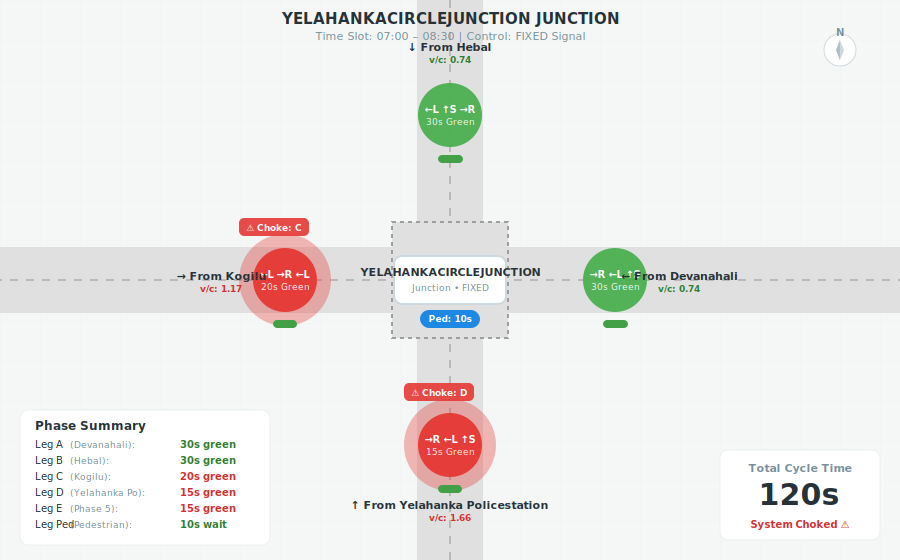

💾 Saved: yelahanka 1_YELAHANKACIRCLEJUNCTION_YELAHANKAPOLICES.svg


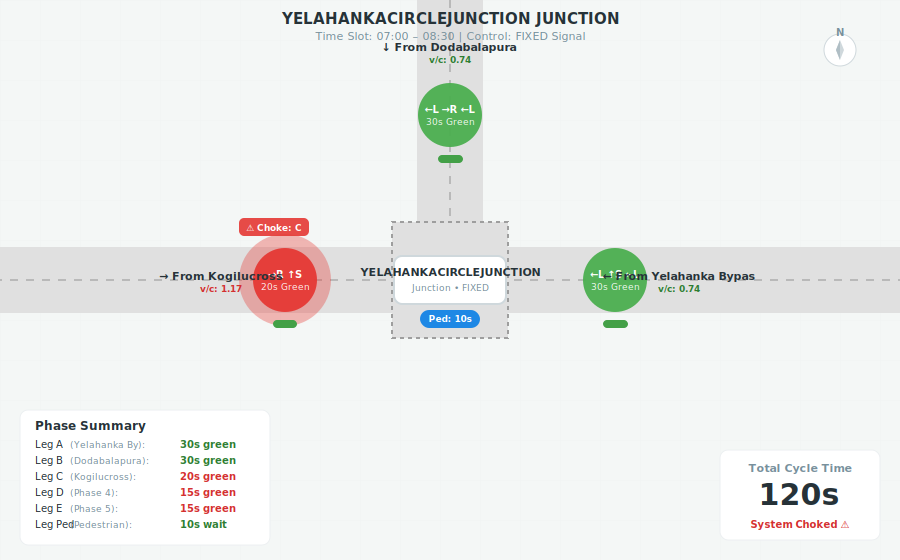

In [265]:
# ── Cell 8: Render & save all junctions ───────────────────────────────────
TIME_SLOT = 1   # 0=07-08 off-peak | 1=08-11 peak | 2=11-16:30 | 3=16:30-21 | 4=21-23
stem = Path(PDF_PATH).stem

for jn in junction_json["junctions"]:
    jn["vc_analysis"] = compute_vc_ratios(jn, TIME_SLOT)
    svg_str  = render_junction_svg(jn, TIME_SLOT)
    safe     = re.sub(r'[^\w]', '_', jn['name'])[:40]
    out_path = f"{stem}_{safe}.svg"

    with open(out_path, "w", encoding="utf-8") as f:
        f.write(svg_str)
    print(f"💾 Saved: {out_path}")

    short = re.sub(r'\s*\(.*?\)', '', jn['name']).split(',')[0].strip()
    display(HTML(f'<h3 style="color:#90caf9;font-family:monospace;margin-bottom:4px">'
                 f'📍 {short} [{jn["control"]}]</h3>'))
    display(SVG(svg_str))
    display(HTML('<hr style="border-color:#333;margin:8px 0"/>'))

---
## Step 5 — Interactive Time-Slot Explorer

In [266]:
# ── Cell 9: ipywidgets explorer ────────────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    # Build time-slot options from the first junction with timings
    all_slots = []
    for jn in junction_json["junctions"]:
        for i, t in enumerate(jn.get("timings", [])):
            lbl = f"{t['from_time']}–{t['to_time']}"
            if (i, lbl) not in [(s[0], s[1]) for s in all_slots]:
                all_slots.append((i, lbl))

    jn_names    = [jn["name"] for jn in junction_json["junctions"]]
    jn_drop     = widgets.Dropdown(options=jn_names, description="Junction:",
                                    style={"description_width": "80px"})
    slot_drop   = widgets.Dropdown(
                    options=[(lbl, idx) for idx, lbl in all_slots],
                    description="Time band:",
                    style={"description_width": "80px"})
    out = widgets.Output()

    def redraw(_=None):
        with out:
            clear_output(wait=True)
            sel_jn   = next(j for j in junction_json["junctions"] if j["name"] == jn_drop.value)
            slot_idx = slot_drop.value
            sel_jn["vc_analysis"] = compute_vc_ratios(sel_jn, slot_idx)
            svg_str  = render_junction_svg(sel_jn, slot_idx)
            display(SVG(svg_str))

    jn_drop.observe(redraw, names="value")
    slot_drop.observe(redraw, names="value")

    display(widgets.HBox([jn_drop, slot_drop]))
    display(out)
    redraw()

except ImportError:
    print("ℹ️  ipywidgets not available — static SVGs above are fully functional.")
    print("    Install with: pip install ipywidgets")

Output()

---
## Appendix — Output JSON Schema

```json
{
  "junctions": [
    {
      "id": 1,
      "name": "AISHWARYA JUNCTION (7th Mn. 1st Block Koramangala)",
      "control": "FIXED",
      "canvas": { "width": 900, "height": 560, "cx": 450, "cy": 280 },
      "approaches": [
        {
          "leg": "A",  "from": "UCO BANK",  "direction": "E",
          "movements": ["L","S"],  "angle_deg": 0,  "cx": 615,  "cy": 280
        }
      ],
      "timings": [
        {
          "from_time": "08:00",  "to_time": "11:00",
          "phase_greens": [ {"weekday": 90, "sunday": 70}, … ],
          "ped_phase":    {"weekday": 10, "sunday": 10},
          "cycle_time":   {"weekday": 190, "sunday": 145}
        }
      ],
      "vc_analysis": [
        {
          "phase": "A",  "from": "UCO BANK",  "green_weekday": 90,
          "cycle": 190,  "vc_ratio": 1.06,  "status": "critical"
        }
      ]
    }
  ]
}
```

### Status thresholds
| Status | v/c range | Indicator |
|--------|-----------|----------|
| `ok` | ≤ 0.85 | Green bubble |
| `warning` | 0.85–1.00 | Orange bubble |
| `critical` | > 1.00 | Red bubble + choke badge |